# Module 04 - Tokenization

Use this notebook as the working space for the Module 04 exercises. Keep `notebooks/clean/` pristine; work in the copy created under `notebooks/solutions/`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt

from g2c.artifacts import find_repo_root
from g2c.tokenizer import BPETokenizer

## Before the Notebook

Use the tests to implement the tokenizer pieces first. The notebook assumes `_get_pair_counts`, `_merge`, `train_step`, `encode`, and `decode` are available as you progress. The scaffolded `train()` loop, Rust-backed `train_fast()`/`encode_fast()`, and tokenizer save/load helpers are implemented for you.

In [ ]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_tokenizer.py -x"
"Question: Which tokenizer test is the next one failing, and what implementation does it point at?"
"Answer: "

## Exercise 1 - Pair Counts and Merge

These two helpers are the BPE algorithm's core data-structure operations. Predict the outputs before running your implementation.

In [ ]:
"Question: What adjacent-pair counts should [1, 2, 1, 2, 3] produce?"
"Answer: "

"Question: Why does a list of length n have only n - 1 adjacent pairs?"
"Answer: "

"Question: What should _merge([1, 1, 1], (1, 1), 99) return, and why?"
"Answer: "

In [ ]:
pair_count_example = [1, 2, 1, 2, 3]
merge_example = [1, 1, 1]

print(BPETokenizer._get_pair_counts(pair_count_example))
print(BPETokenizer._merge(merge_example, (1, 1), 99))

## Exercise 2 - Train BPE on a Tiny Corpus

Train on a very small repeated string first. Call one `train_step()` by hand, then let scaffolded `train()` repeat that step until the target vocabulary size is reached. This makes the learned merges easy to inspect by hand.

In [ ]:
tiny_corpus = "the the the"

"Question: In the initial byte sequence for 'the the the', which adjacent pair should be most frequent?"
"Answer: "

"Question: If the target vocab size is 259, how many merges should be learned from a fresh tokenizer?"
"Answer: "

"Question: Why should the new token IDs start at 256?"
"Answer: "

In [ ]:
step_tok = BPETokenizer()
step_ids = list(tiny_corpus.encode("utf-8"))

print("one step:", step_tok.train_step(step_ids, new_id=len(step_tok.vocab)))
print("merges after one step:", step_tok.merges)
print("learned vocab after one step:", {i: step_tok.vocab[i] for i in range(256, len(step_tok.vocab))})


def print_bpe_progress(info: dict) -> None:
    print(
        f"step {info['steps']} | "
        f"vocab {info['vocab_size']}/{info['target_vocab_size']} | "
        f"last token {info['last_token_repr']} | "
        f"tokens {info['tokens']} | "
        f"last merge count {info['last_merge_count']} | "
        f"elapsed {info['elapsed_seconds']:.3f}s"
    )


tiny_tok = BPETokenizer()
tiny_tok.train(tiny_corpus, vocab_size=259, progress_callback=print_bpe_progress, progress_every=1)
print("merges:", tiny_tok.merges)
print("learned vocab:", {i: tiny_tok.vocab[i] for i in range(256, len(tiny_tok.vocab))})
assert len(tiny_tok.vocab) == 259

## Exercise 3 - Encode, Decode, and Round Trip

A byte-level tokenizer should round-trip any UTF-8 text, including text with characters that were not in the training corpus.

In [ ]:
"Question: Why can a byte-level tokenizer encode text it never saw during training?"
"Answer: "

"Question: During encode, why should the learned merge with the lowest new ID get priority?"
"Answer: "

"Question: What property of vocab entries makes decode lossless?"
"Answer: "

In [ ]:
roundtrip_texts = [
    "the theater there",
    "héllo wörld",
    "unseen text 12345 🌍",
]

roundtrip_tok = BPETokenizer()
roundtrip_tok.train("the quick brown fox jumps over the lazy dog " * 20, vocab_size=300)
for text in roundtrip_texts:
    ids = roundtrip_tok.encode(text)
    decoded = roundtrip_tok.decode(ids)
    print(text, "->", ids, "->", decoded)
    assert decoded == text

## Exercise 4 - Vocab Size vs Compression

Train several tokenizers at different vocab sizes and compare how many tokens they use for the same passage. The default corpus below is small for quick iteration; replace it with a larger text file for the full experiment.

In [ ]:
def load_tokenizer_corpus(path: str | Path | None = None) -> str:
    """Load a text corpus, or use a small built-in corpus for smoke runs."""
    if path is not None:
        return Path(path).read_text(encoding="utf-8")

    paragraph = """
    The quick brown fox jumps over the lazy dog. The theater is there,
    and the theory of tokenization is that frequent text fragments become
    shorter symbols. In a small corpus, common words repeat; in a large corpus,
    BPE discovers useful subwords like ing, tion, the, and spaces before words.
    """
    return "\n".join(line.strip() for line in paragraph.splitlines() if line.strip()) * 40


corpus = load_tokenizer_corpus()
passage = corpus[:300]
print("corpus characters:", len(corpus))
print("passage characters:", len(passage))

In [ ]:
"Question: What do you predict will happen to token count as vocab size increases?"
"Answer: "

"Question: Why might the improvement show diminishing returns?"
"Answer: "

"Question: What is the tradeoff of using a very large vocabulary in a real model?"
"Answer: "

In [ ]:
def train_and_measure(corpus: str, passage: str, vocab_sizes: list[int]) -> list[dict]:
    """Train tokenizers and return compression statistics.

    Each result row should contain:
      - vocab_size_requested
      - vocab_size_actual
      - token_count
      - byte_count
      - chars_per_token
      - tokenizer
    """
    rows = []
    for vocab_size in vocab_sizes:
        # TODO: create BPETokenizer()
        # TODO: train it on corpus at vocab_size
        # TODO: encode passage
        # TODO: append a result dict with the fields listed above
        raise NotImplementedError("measure compression at each vocab size")
    return rows

In [ ]:
# Use small vocab sizes for the built-in corpus. For a larger corpus, try [256, 1024, 8192].
vocab_sizes = [256, 300, 400]

compression_rows = train_and_measure(corpus, passage, vocab_sizes)
for row in compression_rows:
    printable = {k: v for k, v in row.items() if k != "tokenizer"}
    print(printable)

plt.plot(
    [row["vocab_size_actual"] for row in compression_rows],
    [row["token_count"] for row in compression_rows],
    marker="o",
)
plt.xlabel("actual vocab size")
plt.ylabel("tokens in fixed passage")
plt.title("BPE compression improves as vocab grows")
plt.show()

## Exercise 5 - Inspect Learned Tokens

Print early and late learned vocab entries. Early learned IDs should usually be short, high-frequency byte patterns. Later learned IDs tend to be longer and more corpus-specific.

In [ ]:
"Question: Why should token IDs just above 255 usually represent very common patterns?"
"Answer: "

"Question: What kind of learned token would count as corpus-specific rather than generally useful?"
"Answer: "

In [ ]:
def token_bytes_display(token_bytes: bytes) -> str:
    """Display bytes as text when possible, with escapes for non-printing bytes."""
    return token_bytes.decode("utf-8", errors="backslashreplace")


def learned_vocab_window(tok: BPETokenizer, n: int = 20) -> tuple[list[tuple[int, str]], list[tuple[int, str]]]:
    """Return first and last n learned vocab entries as printable pairs."""
    # TODO: collect learned IDs, i.e. IDs >= 256
    # TODO: return first n and last n entries as (id, display_text) tuples
    raise NotImplementedError("inspect learned vocab entries")

In [ ]:
largest_tok = compression_rows[-1]["tokenizer"]
first_tokens, last_tokens = learned_vocab_window(largest_tok, n=20)

print("First learned tokens:")
for token_id, text in first_tokens:
    print(token_id, repr(text))

print("\nLast learned tokens:")
for token_id, text in last_tokens:
    print(token_id, repr(text))

In [ ]:
"Question: Name two early learned tokens and explain why they are plausible frequent patterns."
"Answer: "

"Question: Name one late learned token and explain what makes it more specific."
"Answer: "

## Exercise 6 - Optional Pre-Tokenization

GPT-2-style tokenizers split text before BPE so merges do not freely cross every boundary. This is optional; treat it as an extension after the core tokenizer passes tests.

In [ ]:
"Question: Why might merging across whitespace create less useful tokens?"
"Answer: "

"Question: What would you compare before and after adding pre-tokenization?"
"Answer: "

## Mini Milestone - Train Reusable Tokenizer Artifacts

The exercises above teach the BPE algorithm. This section turns that implementation into reusable course artifacts: trained tokenizers, encoded token streams, and inspection views that make the learned tokenization visible. Run this after the tokenizer tests pass.

Artifacts are written under `artifacts/tokenizers/`. Later modules can load the saved tokenizer JSON and token ID stream instead of retraining BPE from scratch. The package code in `g2c.artifacts` handles path detection, corpus loading, artifact detection, manifests, and save/load; this notebook keeps the corpus choices and visual inspection.

### Setup Helpers

Run these cells once. The package owns the reusable artifact plumbing; the notebook defines only display callbacks and inspection helpers.

In [2]:
from collections import Counter
import random
import time

from IPython.display import Markdown, display

from g2c.artifacts import (
    TokenizerArtifact,
    TokenizerArtifactConfig,
    tokenizer_artifacts_root,
    train_or_load_tokenizer_artifact,
)

repo_root = find_repo_root()
tokenizer_artifact_root = tokenizer_artifacts_root(repo_root)
FORCE_RETRAIN_TOKENIZERS = False
print("tokenizer artifacts:", tokenizer_artifact_root.relative_to(repo_root))

tokenizer artifacts: artifacts/tokenizers


In [3]:
def make_artifact_display(label: str):
    start = time.perf_counter()
    progress = None

    def show(message: Markdown) -> None:
        nonlocal progress
        if progress is None:
            progress = display(message, display_id=True)
        else:
            progress.update(message)

    def update(info: dict) -> None:
        phase = info.get("phase")
        if phase == "loaded":
            print(f"loaded {label}: {info['token_count']:,} token IDs")
        elif phase == "missing_source":
            print(f"Skipping {label}: source {info['source']!r} is not available.")
        elif phase == "fast_start":
            show(
                Markdown(
                    f"{label}: Rust-backed training starting "
                    f"| chars `{info['chars']:,}` "
                    f"| chunks `{info['chunks']:,}` "
                    f"| target vocab `{info['target_vocab_size']:,}`"
                )
            )
        elif phase == "fast_chunks_start":
            show(
                Markdown(
                    f"{label}: preparing text chunks "
                    f"| chars `{info['chars']:,}` "
                    f"| chunks `{info['chunks']:,}`"
                )
            )
        elif phase == "fast_chunk":
            chunk_index = int(info["chunk_index"])
            chunks = int(info["chunks"])
            width = 28
            filled = max(1, min(width, round(width * chunk_index / chunks)))
            bar = "#" * filled + "-" * (width - filled)
            show(
                Markdown(
                    f"{label}: ingesting text chunks `[{bar}]` "
                    f"`{chunk_index:,}/{chunks:,}` "
                    f"| chars `{info['chars_seen']:,}/{info['chars']:,}` "
                    f"| elapsed `{time.perf_counter() - start:.1f}s`"
                )
            )
        elif phase == "fast_native_train_start":
            show(
                Markdown(
                    f"{label}: starting Rust tokenizer trainer... "
                    f"| target vocab `{info['target_vocab_size']:,}` "
                    f"| chunks `{info['chunks']:,}` "
                    f"| elapsed `{time.perf_counter() - start:.1f}s`"
                )
            )
        elif phase == "fast_native_progress":
            current = int(info["current"])
            total = max(1, int(info["total"]))
            width = 28
            filled = max(1, min(width, round(width * current / total)))
            bar = "#" * filled + "-" * (width - filled)
            show(
                Markdown(
                    f"{label}: {info['native_stage']} `[{bar}]` "
                    f"`{current:,}/{total:,}` "
                    f"| elapsed `{time.perf_counter() - start:.1f}s`"
                )
            )
        elif phase == "fast_chunks_done":
            show(
                Markdown(
                    f"{label}: Rust BPE training complete; exporting learned merges... "
                    f"| chunks `{info['chunks']:,}` "
                    f"| elapsed `{time.perf_counter() - start:.1f}s`"
                )
            )
        elif phase == "fast_encode_start":
            show(
                Markdown(
                    f"{label}: encoding corpus with learned tokenizer... "
                    f"| vocab `{info['vocab_size']:,}/{info['target_vocab_size']:,}` "
                    f"| elapsed `{time.perf_counter() - start:.1f}s`"
                )
            )
        elif phase == "fast_done":
            show(
                Markdown(
                    f"{label}: trained vocab `{info['vocab_size']:,}/{info['target_vocab_size']:,}` "
                    f"| tokens `{info['token_count']:,}` "
                    f"| chunks `{info['chunks']:,}` "
                    f"| elapsed `{info['elapsed_seconds']:.1f}s`"
                )
            )
        elif phase == "saved":
            print(f"saved {label}: {info['token_count']:,} token IDs")
        elif {"vocab_size", "target_vocab_size", "steps", "tokens", "last_merge_count"}.issubset(info):
            if progress is None:
                show(Markdown(f"{label} tokenizer training starting..."))
            last_token = info.get("last_token_repr")
            if last_token is None:
                last_token = "None"
            last_token = str(last_token).replace("`", "\`")
            elapsed = info.get("elapsed_seconds", time.perf_counter() - start)
            show(
                Markdown(
                    f"{label}: vocab `{info['vocab_size']:,}/{info['target_vocab_size']:,}` "
                    f"| steps `{info['steps']:,}` "
                    f"| tokens `{info['tokens']:,}` "
                    f"| last token `{last_token}` "
                    f"| last count `{info['last_merge_count']}` "
                    f"| elapsed `{elapsed:.1f}s`"
                )
            )
        elif phase is not None:
            show(Markdown(f"{label}: `{phase}` | elapsed `{time.perf_counter() - start:.1f}s`"))

    return update

In [4]:
def display_token_bytes(token_bytes: bytes) -> str:
    text = token_bytes.decode("utf-8", errors="backslashreplace")
    return text.replace("\n", "\\n").replace("\t", "\\t")


def shorten(text: str, width: int = 36) -> str:
    return text if len(text) <= width else text[: width - 1] + "…"


def deterministic_text_window(text: str, *, chars: int = 360, seed: int = 0) -> str:
    if len(text) <= chars:
        return text
    rng = random.Random(seed)
    start = rng.randrange(0, len(text) - chars)
    return text[start : start + chars]


def token_strings(tokenizer: BPETokenizer, text: str) -> list[str]:
    return [display_token_bytes(tokenizer.vocab[token_id]) for token_id in tokenizer.encode_fast(text)]


def most_frequent_final_tokens(
    tokenizer: BPETokenizer,
    text: str,
    *,
    top_n: int = 20,
    max_chars: int = 200_000,
    learned_only: bool = False,
) -> list[tuple[int, str, int, int]]:
    ids = tokenizer.encode_fast(text[:max_chars])
    min_token_id = 256 if learned_only else 0
    counts = Counter(token_id for token_id in ids if token_id >= min_token_id)
    rows = []
    for token_id, count in counts.most_common(top_n):
        token_text = display_token_bytes(tokenizer.vocab[token_id])
        rows.append((token_id, token_text, count, len(tokenizer.vocab[token_id])))
    return rows


def longest_learned_tokens(tokenizer: BPETokenizer, *, top_n: int = 20) -> list[tuple[int, int, str]]:
    learned_ids = [token_id for token_id in tokenizer.vocab if token_id >= 256]
    learned_ids.sort(key=lambda token_id: (len(tokenizer.vocab[token_id]), token_id), reverse=True)
    selected_token_bytes: list[bytes] = []
    rows = []
    for token_id in learned_ids:
        token_bytes = tokenizer.vocab[token_id]
        if any(token_bytes in selected for selected in selected_token_bytes):
            continue
        selected_token_bytes.append(token_bytes)
        rows.append((token_id, len(token_bytes), display_token_bytes(token_bytes)))
        if len(rows) >= top_n:
            break
    return rows


def print_rows(title: str, headers: tuple[str, ...], rows: list[tuple]) -> None:
    print("\n" + title)
    print(" | ".join(headers))
    print("-" * 72)
    for row in rows:
        print(" | ".join(str(value) for value in row))


def plot_frequency_rows(rows: list[tuple[int, str, int, int]], *, title: str) -> None:
    if not rows:
        print("No tokens found in this encoded sample.")
        return
    labels = [shorten(repr(token), 28) for _, token, _, _ in reversed(rows)]
    counts = [count for _, _, count, _ in reversed(rows)]
    plt.figure(figsize=(8, max(4, len(rows) * 0.28)))
    plt.barh(labels, counts)
    plt.xlabel("count in encoded sample")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def inspect_tokenizer_artifact(artifact: TokenizerArtifact, *, seed: int = 13) -> None:
    tokenizer = artifact.tokenizer
    text = artifact.text
    if not text:
        print(f"Skipping inspection for {artifact.config.name}: no source text loaded.")
        return

    name = artifact.config.name
    manifest = artifact.manifest
    print("=" * 88)
    print(name)
    print("trainer:", manifest.get("trainer", "unknown"))
    print("vocab size:", manifest["actual_vocab_size"])
    print("token count:", manifest["token_count"])
    print("chars/token:", round(manifest["chars_per_token"], 3))

    sample = deterministic_text_window(text, chars=360, seed=seed)
    print("\nSample text:")
    print(repr(sample))
    print("\nToken strings for sample:")
    print(token_strings(tokenizer, sample))

    frequent_rows = most_frequent_final_tokens(tokenizer, text, top_n=20)
    learned_frequent_rows = most_frequent_final_tokens(tokenizer, text, top_n=20, learned_only=True)
    print_rows(
        "Most frequent final tokens after encoding text sample",
        ("token_id", "token", "count", "bytes"),
        [(token_id, repr(shorten(token)), count, length) for token_id, token, count, length in frequent_rows],
    )

    print_rows(
        "Most frequent learned final tokens after encoding text sample",
        ("token_id", "token", "count", "bytes"),
        [(token_id, repr(shorten(token)), count, length) for token_id, token, count, length in learned_frequent_rows],
    )

    longest_rows = longest_learned_tokens(tokenizer, top_n=20)
    print_rows(
        "Longest learned tokens, greedily excluding byte substrings",
        ("token_id", "bytes", "token"),
        [(token_id, length, repr(shorten(token, 120))) for token_id, length, token in longest_rows],
    )

    plot_frequency_rows(learned_frequent_rows, title=f"{name}: most frequent learned final tokens")


def run_and_inspect_tokenizer_artifact(
    config: TokenizerArtifactConfig,
    *,
    enabled: bool = True,
    force: bool = False,
) -> dict | None:
    if not enabled:
        print(f"Skipping {config.name}: disabled for this run.")
        return None
    artifact_display = make_artifact_display(config.name)
    artifact = train_or_load_tokenizer_artifact(
        config,
        repo_root=repo_root,
        force=force,
        progress_callback=artifact_display,
        status_callback=artifact_display,
    )
    if artifact is not None:
        inspect_tokenizer_artifact(artifact)
    return artifact

### TinyShakespeare Tokenizer

TinyShakespeare is small enough to train with the Python scaffolded BPE loop. That is useful here: the saved artifact comes from the same `train_step()` logic you implemented, and the progress display shows each learned token as the vocabulary grows.

loaded ShakespeareTokenizer: 396,408 token IDs
ShakespeareTokenizer
trainer: python-scaffold
vocab size: 1024
token count: 396408
chars/token: 2.523

Sample text:
'he bloody king.\nAnd here he comes.\nAll hail, my sovereign liege!\n\nKING RICHARD III:\nKind Tyrrel, am I happy in thy news?\n\nTYRREL:\nIf to have done the thing you gave in charge\nBeget your happiness, be happy then,\nFor it is done, my lord.\n\nKING RICHARD III:\nBut didst thou see them dead?\n\nTYRREL:\nI did, my lord.\n\nKING RICHARD III:\nAnd buried, gentle Tyrrel?\n\nTY'

Token strings for sample:
['he ', 'b', 'loo', 'dy ', 'king', '.\\n', 'And ', 'here ', 'he ', 'com', 'es', '.\\n', 'A', 'll ', 'ha', 'il', ', my ', 'so', 'ver', 'e', 'ign', ' ', 'lie', 'ge', '!\\n\\n', 'KING ', 'RICHARD II', 'I', ':\\n', 'K', 'ind ', 'T', 'y', 'r', 're', 'l', ', ', 'am', ' I ', 'ha', 'pp', 'y ', 'in', ' thy ', 'new', 's', '?\\n\\n', 'T', 'Y', 'R', 'R', 'EL', ':\\nI', 'f', ' to ', 'have ', 'd', 'one ', 'the ', 'th', 'ing ', 'you', ' 

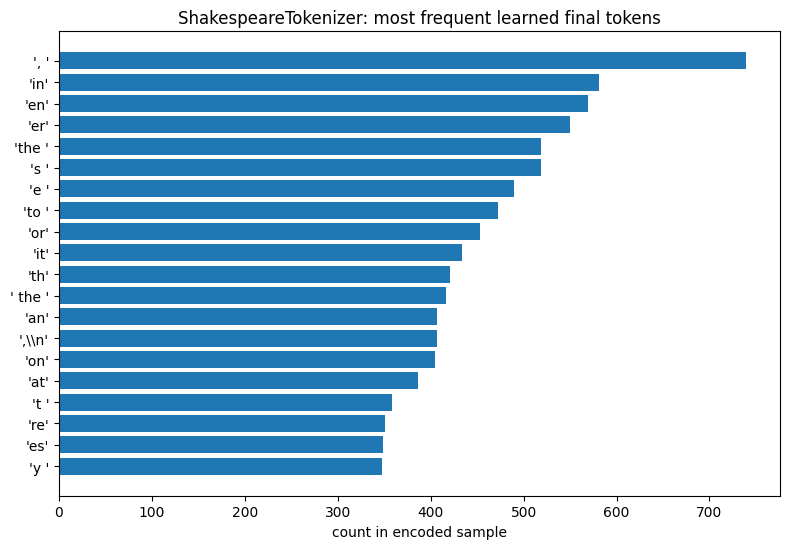

In [5]:
shakespeare_config = TokenizerArtifactConfig(
    name="ShakespeareTokenizer",
    source="tinyshakespeare",
    vocab_size=2048,
    max_chars=1_000_000,
    use_fast=False,
    notes="Small reusable tokenizer for ShakespeareLM smoke and scaling runs.",
)

shakespeare_artifact = run_and_inspect_tokenizer_artifact(
    shakespeare_config,
    force=FORCE_RETRAIN_TOKENIZERS,
)

### TinyStories Tokenizer

TinyStories is much larger, so this cell uses `train_fast()`. The fast path uses the optimized Rust `tokenizers` library, streams the text to that trainer in chunks, then copies the learned merges back into the same `BPETokenizer.merges` and `BPETokenizer.vocab` tables. Functionally it is the same BPE artifact; it just avoids spending notebook time on repeated Python scans.

Run `./datasets.sh --tiny` for the 100MB starter TinyStories file or `./datasets.sh tinystories` for the full local corpus.

loaded StoryTokenizer: 9,439,684 token IDs
StoryTokenizer
trainer: rust-tokenizers
vocab size: 4096
token count: 9439684
chars/token: 5.293

Sample text:
'They watched the butterfly for a while before saying goodbye and going home. Lily was happy to have made a new friend and had a fun day jogging in the park.\n<|endoftext|>\nOnce upon a time, there was a little girl named Lily. She loved to play outside in the garden. One day, she saw a little ant walking on the ground. The ant was very small and Lily thought i'

Token strings for sample:
['They ', 'watched the ', 'butterfly ', 'for a ', 'while ', 'before ', 'say', 'ing ', 'goodby', 'e and ', 'going ', 'hom', 'e. ', 'Lily was ', 'happy to have ', 'made a ', 'new ', 'friend ', 'and ', 'had a ', 'fun ', 'day ', 'jo', 'gg', 'ing ', 'in the park', '.\\n<|endoftext|>\\nOnce upon a time, there was a little girl named Lily. She loved to play ', 'outside ', 'in the garden', '. One day, she ', 'saw a ', 'little ', 'ant ', 'walking ', 'on the g

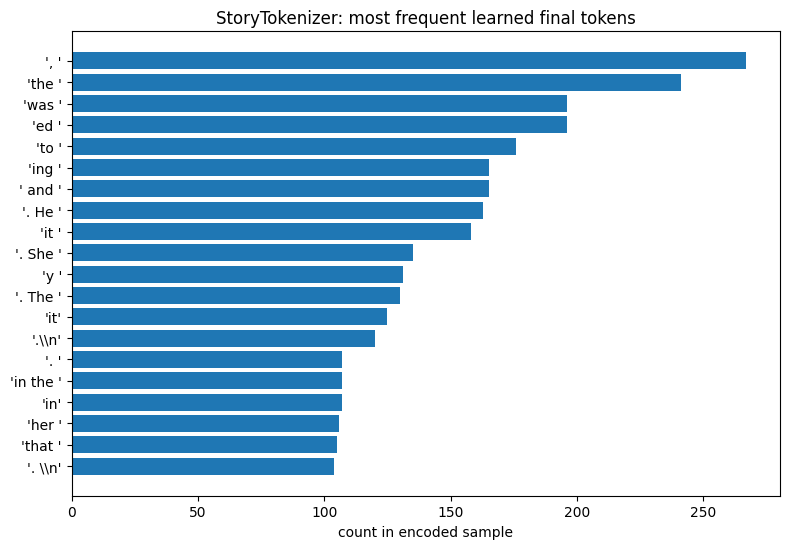

In [7]:
RUN_TINYSTORIES_TOKENIZER = True

story_config = TokenizerArtifactConfig(
    name="StoryTokenizer",
    source="tinystories",
    vocab_size=4096,
    max_chars=50_000_000,
    use_fast=True,
    chunk_chars=8_192,
    notes="TinyStories tokenizer for StoryLM. Increase max_chars when you want the durable artifact.",
)

story_artifact = run_and_inspect_tokenizer_artifact(
    story_config,
    enabled=RUN_TINYSTORIES_TOKENIZER,
    force=FORCE_RETRAIN_TOKENIZERS,
)

### G2C Corpus Tokenizer

The G2C corpus mixes course text with broader educational/code data for later TinyLLM experiments. It should also use `train_fast()`: the corpus is meant to be big enough that the Python teaching loop becomes the wrong tool for artifact generation.

Run `./datasets.sh --small` to create the small corpus first. The logical `g2c` source automatically uses the full corpus if it exists, otherwise it falls back to the small corpus.

G2CTokenizer: trained vocab `16,380/16,384` | tokens `19,359,166` | chunks `12,167` | elapsed `185.9s`

saved G2CTokenizer: 19,359,166 token IDs
G2CTokenizer
trainer: rust-tokenizers
vocab size: 16380
token count: 19359166
chars/token: 5.148

Sample text:
'enter of attention. Siamese cats thrive on human interaction and are known to form strong bonds with their owners. They often follow their humans around the house, offering constant companionship and loyalty.\nSiamese cats are also known for their vocal nature. They have a wide range of vocalizations and are not afraid to use them to communicate their needs o'

Token strings for sample:
['ent', 'er of ', 'attention', '. S', 'i', 'am', 'ese ', 'cats ', 'thrive ', 'on ', 'human ', 'inter', 'ac', 'tion and ', 'are ', 'known ', 'to ', 'form ', 'strong ', 'bond', 's with ', 'their ', 'own', 'ers', '. They ', 'often ', 'follow ', 'their ', 'humans ', 'around the ', 'house, ', 'offering ', 'constant ', 'companion', 'ship and ', 'loyal', 'ty', '.\\nS', 'i', 'am', 'ese ', 'cat', 's are also ', 'known ', 'for their ', 'voc', 'al ', 'nature', '. 

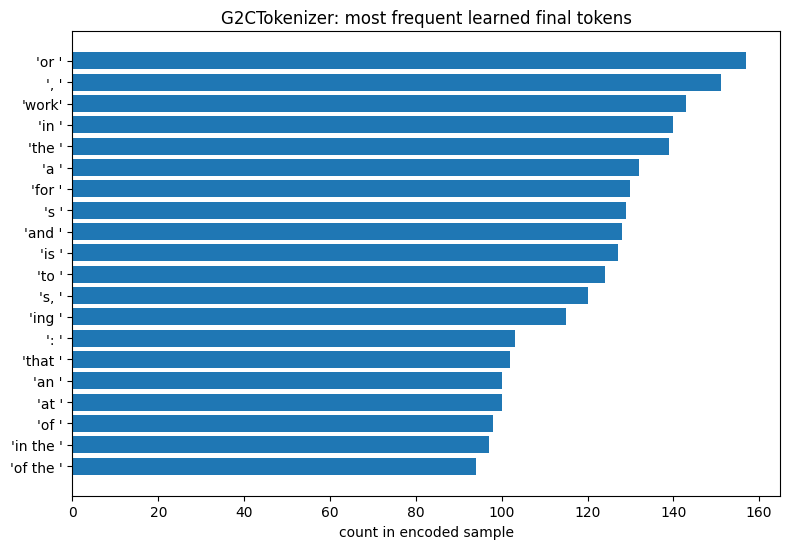

In [8]:
RUN_G2C_CORPUS_TOKENIZER = True

g2c_config = TokenizerArtifactConfig(
    name="G2CTokenizer",
    source="g2c",
    vocab_size=16384,
    max_chars=100_000_000,
    use_fast=True,
    chunk_chars=8_192,
    notes="Broad course-corpus tokenizer for TinyLLM-small experiments.",
)

g2c_artifact = run_and_inspect_tokenizer_artifact(
    g2c_config,
    enabled=RUN_G2C_CORPUS_TOKENIZER,
    force=FORCE_RETRAIN_TOKENIZERS,
)

## Submission Notes

When complete, ask a coding agent to grade your Module 04 notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.